# Supplementary Figures S4–S5: grouped non-spatial analyses

The calculation cells read the included cell arrays and result tables, recalculate every displayed summary, and draw S4 and S5. The steps below show how raw data proceeds through Full and No-interaction training, evaluation, attribution, and dataset-specific panel preparation.

## Run the notebook

The plotting cells use numerical files included with CytoBridge and write new
PDF and PNG files. The steps below list the commands and source files that
produced those inputs. Each step names what it reads, what it writes, and what
comes next.

A command can be repeated when you have the inputs named under **Start with**.
**Source files** points to calculation code kept with the paper results. The
plotting cells use a new run only when the final plotting command explicitly
accepts that run's result directory. The paper figure index marks notebooks
where this conversion step is not yet available.

Replace text inside angle brackets with your path or value. For example,
`<output-dir>` means the directory where you want the files to be written.

### 1. prepare model input (S4 Weinreb; S5 scNT)

```text
cytobridge nonspatial prepare --dataset <dataset> --input-h5ad <raw.h5ad> --output-dir <run>/preprocess
```

Start with: `raw expression H5AD and dataset configuration`

Writes: `<run>/preprocess/model_input_50pc.h5ad; lr_expression.h5ad; pca_artifacts.npz; preprocess_manifest.json`

Next: `build prior`


Run this command twice to reproduce both figures: use --dataset weinreb for S4 and --dataset scnt_cortex for S5. Each code block is one command.

### 2. build the LR edge prior (S4 Weinreb; S5 scNT)

```text
cytobridge nonspatial build-prior --dataset <dataset> --preprocess-manifest <run>/preprocess/preprocess_manifest.json --output-dir <run>/edge_prior --device cuda:0
```

Start with: `preprocess_manifest.json; lr_expression.h5ad; bundled mouse LR database`

Writes: `<run>/edge_prior predictor, graph inputs, and manifest.json`

Next: `train the Full model`

### 3. train the Full model (S4 Weinreb; S5 scNT)

```text
cytobridge nonspatial train --dataset <dataset> --arm full --preprocess-manifest <run>/preprocess/preprocess_manifest.json --edge-prior-manifest <run>/edge_prior/manifest.json --output-dir <run>/full --device cuda:0
```

Start with: `preprocess_manifest.json; edge-prior manifest; Full-arm configuration`

Writes: `<run>/full/model checkpoints; resolved configuration; training summary`

Next: `train the No-interaction model with the same settings`

### 4. train the No-interaction model with the same settings (S4 Weinreb; S5 scNT)

```text
cytobridge nonspatial train --dataset <dataset> --arm no_interaction --preprocess-manifest <run>/preprocess/preprocess_manifest.json --output-dir <run>/no_interaction --device cuda:0
```

Start with: `preprocess_manifest.json; No-interaction-arm configuration`

Writes: `<run>/no_interaction/model checkpoints; resolved configuration; training summary`

Next: `compare the two models`

### 5. compare the two trained models (S4c/S5c)

```text
cytobridge nonspatial evaluate --dataset <dataset> --prepared-h5ad <run>/preprocess/model_input_50pc.h5ad --full-run-dir <run>/full --no-interaction-run-dir <run>/no_interaction --output-dir <run>/evaluation --inference-seed 10000 --inference-seed 10001 --device cuda:0
```

Start with: `model_input_50pc.h5ad; Full and No-interaction model directories`

Writes: `distribution metrics and paired trajectory summaries`

Next: `dataset-specific evaluation`

### 6. evaluate Weinreb clone fate (S4d)

```text
cytobridge nonspatial weinreb-clone-fate --prepared-h5ad <run>/preprocess/model_input_50pc.h5ad --full-run-dir <run>/full --no-interaction-run-dir <run>/no_interaction --output-dir <run>/clone_fate --device cuda:0
```

Start with: `prepared lineage labels and both fitted arms`

Writes: `frozen_baseline_clone_fate_summary.csv and its run record`

Next: `assemble S4 panel data`

### 7. evaluate scNT new-RNA direction (S5d)

```text
cytobridge nonspatial scnt-direction --source-h5ad <raw.h5ad> --prepared-h5ad <run>/preprocess/model_input_50pc.h5ad --pca-artifacts-npz <run>/preprocess/pca_artifacts.npz --full-run-dir <run>/full --no-interaction-run-dir <run>/no_interaction --output-dir <run>/scnt_direction --device cuda:0
```

Start with: `reference scNT new-RNA direction and both fitted models`

Writes: `timewise_scnt_direction_alignment.csv and its run record`

Next: `assemble S5 panel data`

### 8. calculate interaction attribution (S4e-f; S5e-f)

```text
cytobridge nonspatial attribution --dataset <dataset> --expression-h5ad <run>/preprocess/lr_expression.h5ad --latent-h5ad <run>/preprocess/model_input_50pc.h5ad --edge-prior-manifest <run>/edge_prior/manifest.json --training-run-dir <run>/full --output-dir <run>/attribution --device cuda:0
```

Start with: `lr_expression.h5ad; model_input_50pc.h5ad; edge-prior record; Full-model directory`

Writes: `GNN message, network, CellChat-comparison, and pathway tables`

Next: `assemble panel data`

### 9. recalculate and draw from the included numerical files (S4/S5)

```text
python scripts/execute_paper_notebooks.py --notebook nonspatial_figures --output-dir <notebook-run>
```

Start with: `included numerical files under nonspatial_figures/*`

Writes: `Supplementary_Figure_S4.pdf/.png; Supplementary_Figure_S5.pdf/.png; derived CSV tables`


The included numerical files reproduce the paper figure. They use the paper's saved Full checkpoint and the corrected No-interaction run; they are not the output of a new matched two-arm run. Steps 1–8 show the public route for producing both arms in a new run. The notebook recalculates the displayed values and draws new PDF and PNG files rather than loading finished figure pages.

## Load figure inputs

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    calculate_nonspatial_panels,
    load_nonspatial_figures,
    plot_nonspatial_figures,
    write_nonspatial_tables,
)

output_dir = Path("outputs") / "nonspatial_figures"
output_dir.mkdir(parents=True, exist_ok=True)
results = load_nonspatial_figures()
{"weinreb_cells": len(results.weinreb.cells.times), "scnt_cells": len(results.scnt.cells.times)}

{'weinreb_cells': 49302, 'scnt_cells': 20547}

## Recalculate panel values

In [2]:
panels = calculate_nonspatial_panels(results)
tables = write_nonspatial_tables(panels, output_dir)
sorted(path.name for path in tables.values())

['scnt_direction.csv',
 'scnt_distribution.csv',
 'scnt_pathways.csv',
 'summary.csv',
 'weinreb_clone_fate.csv',
 'weinreb_concordance.csv',
 'weinreb_distribution.csv',
 'weinreb_pathways.csv']

## Draw and save the figure

In [3]:
figures = plot_nonspatial_figures(results, output_dir, panels)
{figure_id: [path.name for path in paths] for figure_id, paths in figures.items()}

{'s4': ['supplementary_figure_s4_weinreb_nonspatial.pdf',
  'supplementary_figure_s4_weinreb_nonspatial.png'],
 's5': ['supplementary_figure_s5_scnt_nonspatial.pdf',
  'supplementary_figure_s5_scnt_nonspatial.png']}

## Preview the generated figures

These PNG files were written by `plot_nonspatial_figures` in the preceding
cell; they are not input files.

S4


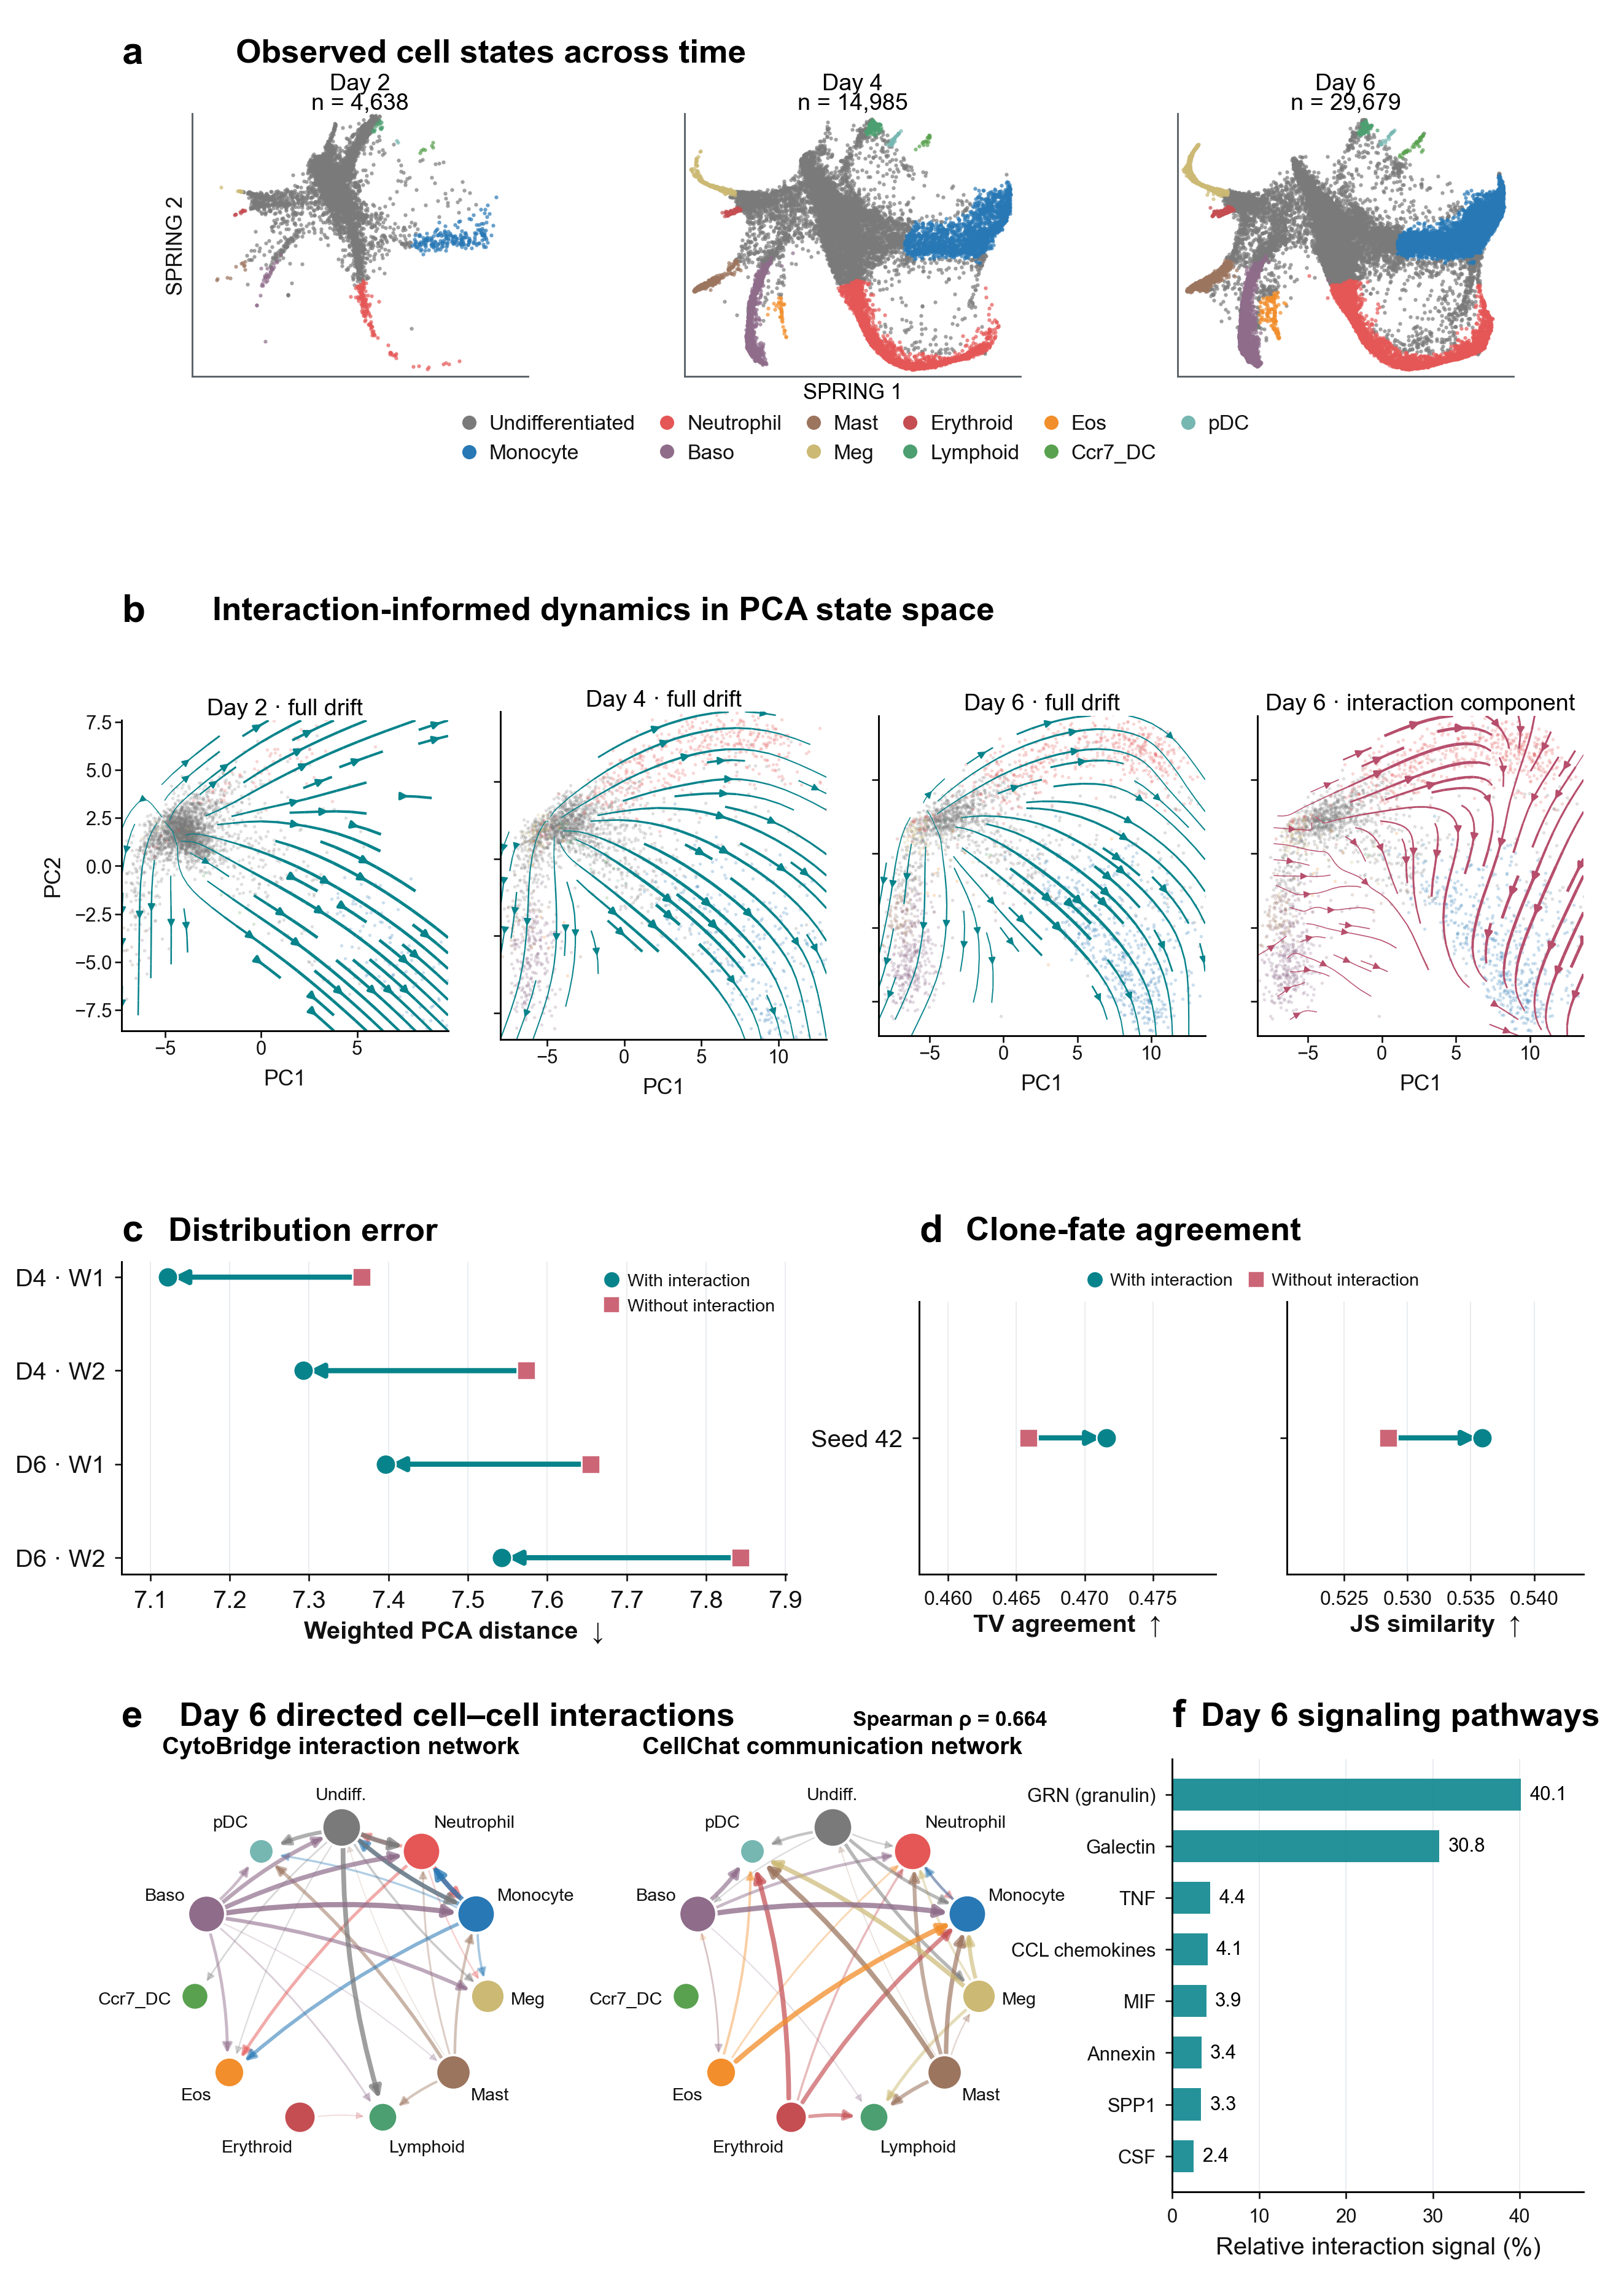

S5


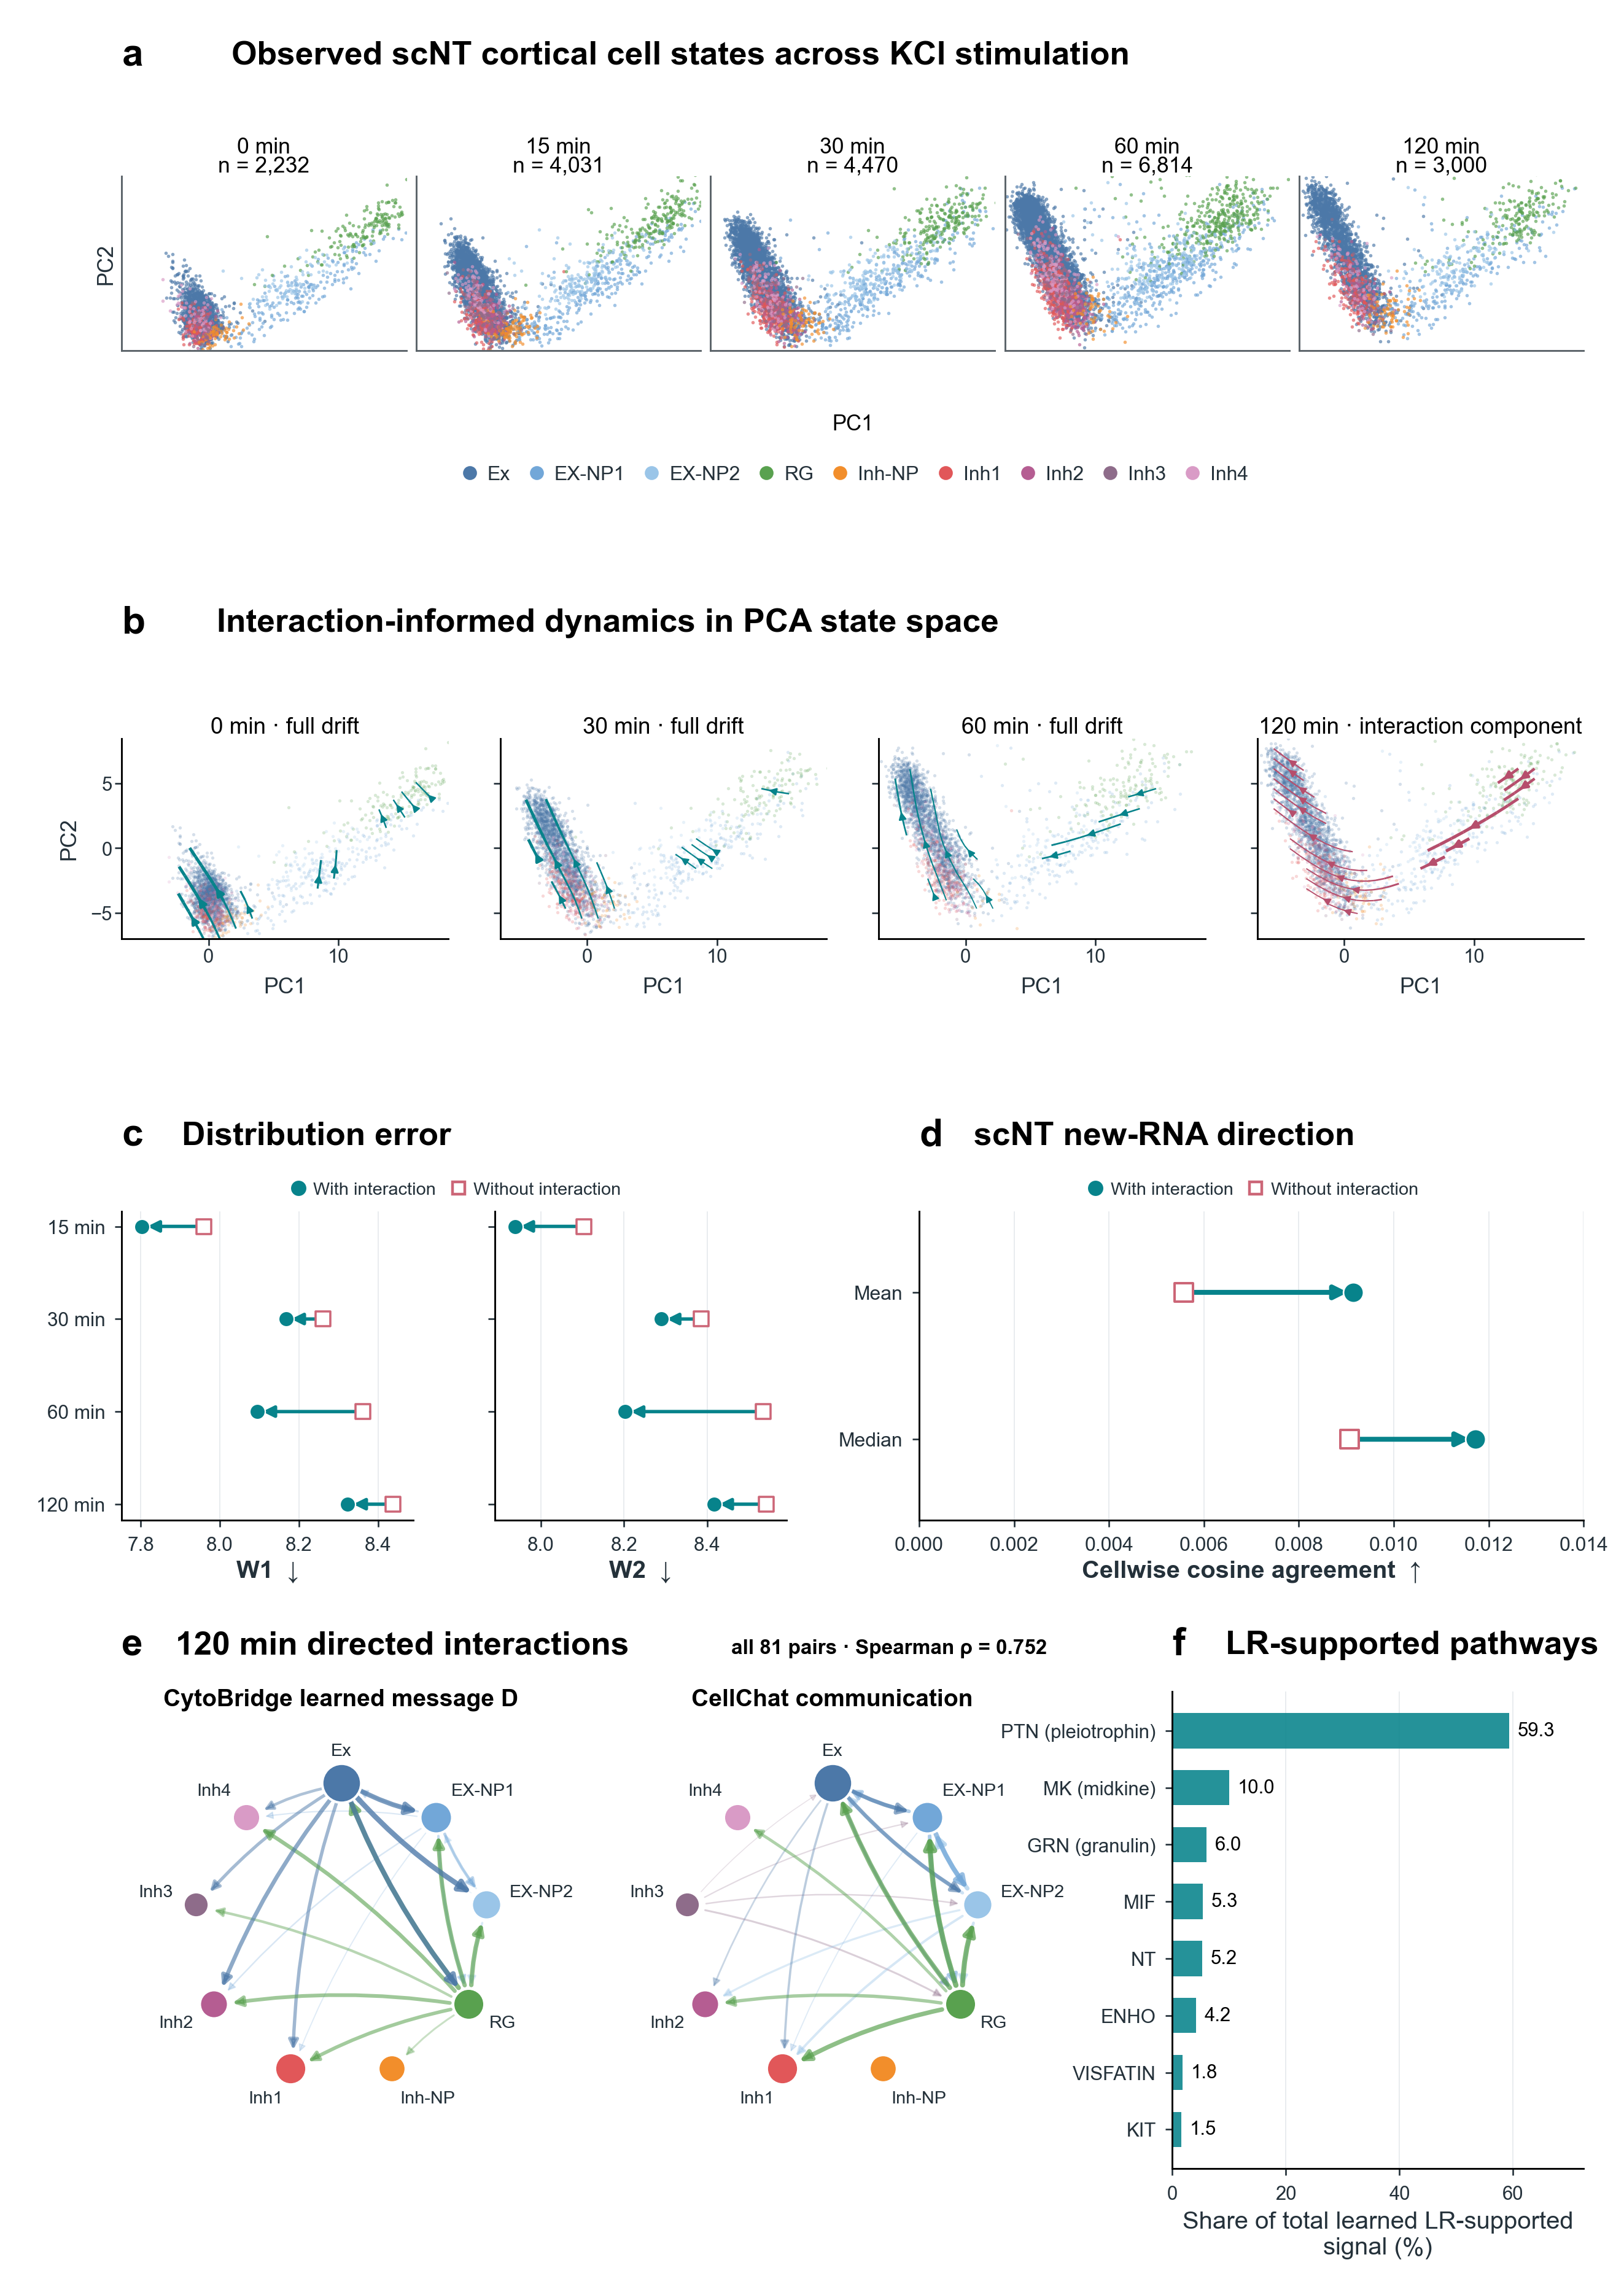

In [4]:
for figure_id, (_, png_path) in figures.items():
    print(figure_id.upper())
    display(Image(filename=str(png_path), width=720))